# Bluesky User Posts — EDA(Start) The rest is designed solely for colab

## 1. Mount Drive

In [13]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Imports

In [14]:
import tarfile
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Dataset Path

In [16]:
TAR_PATH   = "/content/drive/MyDrive/bluesky_filtered/user_posts.tar.gz" # Change to whatever shortcut you saved your path at (lmk if thius works)
SAVE_PATH  = "/content/drive/MyDrive/bluesky_filtered/posts_sample.csv"
SAMPLE_SIZE = 100_000

## 4. Sampling Posts

In [17]:
# inspect a single post to see available fields
with tarfile.open(TAR_PATH, "r|gz") as tar:
    for member in tar:
        if not member.name.endswith(".jsonl"):
            continue
        f = tar.extractfile(member)
        if f is None:
            continue
        line = f.readline()
        post = json.loads(line)
        print("Keys:", list(post.keys()))
        print("\nFull post:")
        print(json.dumps(post, indent=2))
        break

Keys: ['post_id', 'user_id', 'instance', 'date', 'text', 'langs', 'like_count', 'reply_count', 'repost_count', 'reply_to', 'replied_author', 'thread_root', 'thread_root_author', 'repost_from', 'reposted_author', 'quotes', 'quoted_author', 'labels', 'sent_label', 'sent_score']

Full post:
{
  "post_id": 128238232,
  "user_id": 1662063,
  "instance": "bsky.social",
  "date": 202403101740,
  "text": "\u306a\u3093\u3067\u305d\u3093\u306a\u306b\u4ed6\u4eba\u3092\u30b3\u30f3\u30c8\u30ed\u30fc\u30eb\u3057\u305f\u304c\u308b\u3093\u3067\u3057\u3087\u3046\u306d\u3047",
  "langs": [
    "jpn"
  ],
  "like_count": 0,
  "reply_count": 0,
  "repost_count": 0,
  "reply_to": null,
  "replied_author": null,
  "thread_root": null,
  "thread_root_author": null,
  "repost_from": null,
  "reposted_author": null,
  "quotes": null,
  "quoted_author": null,
  "labels": null,
  "sent_label": null,
  "sent_score": null
}


Scanned 2,000,000 posts



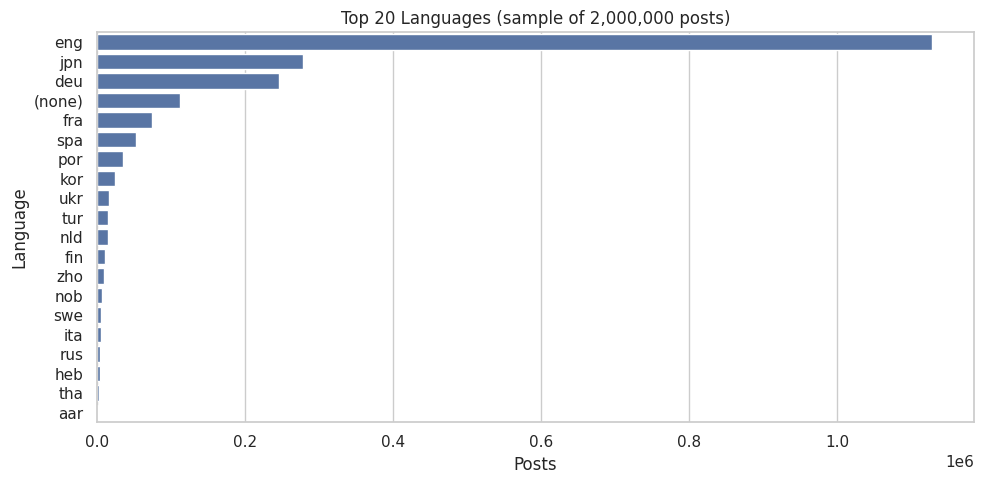

In [18]:
from collections import Counter

lang_counts = Counter()
posts_scanned = 0
MAX_SCAN = 2000_000

with tarfile.open(TAR_PATH, "r|gz") as tar:
    for member in tar:
        if posts_scanned >= MAX_SCAN:
            break
        if not member.name.endswith(".jsonl"):
            continue
        f = tar.extractfile(member)
        if f is None:
            continue
        for line in f:
            if posts_scanned >= MAX_SCAN:
                break
            try:
                post = json.loads(line)
                langs = post.get("langs")
                if not langs:
                    lang_counts["(none)"] += 1
                else:
                    for l in langs:
                        lang_counts[l] += 1
                posts_scanned += 1
            except json.JSONDecodeError:
                continue

print(f"Scanned {posts_scanned:,} posts\n")
lang_df = pd.DataFrame(lang_counts.most_common(20), columns=["lang", "count"])
lang_df["pct"] = (lang_df["count"] / posts_scanned * 100).round(1)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=lang_df, x="count", y="lang", ax=ax)
ax.set(title=f"Top 20 Languages (sample of {posts_scanned:,} posts)", xlabel="Posts", ylabel="Language")
plt.tight_layout()
plt.show()

In [19]:

'''
Currently cause we are streaming from the tar we have to go front first and all the first lot of users are non-english hence why it takes so long (around a minute)
(maybe early adopter to platform or just how theyve structured it). A TODO is to preprocess this data properly by extracting the tar
getting out the 100GB of raw data optimising how we store it instead of json and then well be able to accesss repeatedly and do a true random sampling
with much more flexibility.
'''
import time

records = []
t0 = time.time()

with tarfile.open(TAR_PATH, "r|gz") as tar:
    for member in tar:
        if len(records) >= SAMPLE_SIZE:
            break
        if not member.name.endswith(".jsonl"):
            continue
        f = tar.extractfile(member)
        if f is None:
            continue
        for line in f:
            try:
                post = json.loads(line)
                langs = post.get("langs")
                if langs and "eng" not in langs:
                    break  # skip if non-english user
                records.append({
                    "post_id":      post.get("post_id"),
                    "user_id":      post.get("user_id"),
                    "text":         post.get("text"),
                    "date":         post.get("date"),
                    "like_count":   post.get("like_count"),
                    "reply_count":  post.get("reply_count"),
                    "repost_count": post.get("repost_count"),
                    "is_reply":     post.get("reply_to") is not None,
                    "is_repost":    post.get("repost_from") is not None,
                    "is_quote":     post.get("quotes") is not None,
                    "label" :  post.get("label"),
                    "sent_label" :  post.get("sent_label"),
                    "sent_score": post.get("sent_score"),
                })
                break  #getting just one post per user can adapt accordingly (each jsonl represnt all the posts of a user)
            except json.JSONDecodeError:
                continue

print(f"Done. {len(records):,} posts in {time.time()-t0:.1f}s")

Done. 100,000 posts in 65.9s


## 5. Convert to DataFrame

In [20]:
df = pd.DataFrame(records)

#date format is YYYYMMDDHHmm
df["timestamp"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d%H%M", errors="coerce")
df["text_length"] = df["text"].str.len()

df.head()

,post_id,user_id,text,date,like_count,reply_count,repost_count,is_reply,is_repost,is_quote,label,sent_label,sent_score,timestamp,text_length
0,185310360,1028680,bitcoin spiking just before christmas... i'm r...,202312060142,23,0,3,False,True,False,None,1.0,0.493,2023-12-06 01:42:00,168
1,91191477,265900,Started off #WRAD today with Ms. Drew & her 3r...,202402051549,3,0,0,False,False,False,None,2.0,0.982,2024-02-05 15:49:00,175
2,95619644,3174300,,202307271950,4,1,0,False,False,False,None,NaN,NaN,2023-07-27 19:50:00,0
3,65435247,1535259,He always words these tweets so that he can al...,202403170404,76,1,1,True,False,False,None,0.0,0.743,2024-03-17 04:04:00,152
4,219348625,706124,seen in washington sq park,202403181425,1279,30,209,False,True,False,None,1.0,0.901,2024-03-18 14:25:00,26


## 6. Dataset Inspection

In [21]:
print("Shape:", df.shape)
df.info()

Shape: (100000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   post_id       100000 non-null  int64         
 1   user_id       100000 non-null  int64         
 2   text          100000 non-null  object        
 3   date          100000 non-null  int64         
 4   like_count    100000 non-null  int64         
 5   reply_count   100000 non-null  int64         
 6   repost_count  100000 non-null  int64         
 7   is_reply      100000 non-null  bool          
 8   is_repost     100000 non-null  bool          
 9   is_quote      100000 non-null  bool          
 10  label         0 non-null       object        
 11  sent_label    88590 non-null   float64       
 12  sent_score    88590 non-null   float64       
 13  timestamp     100000 non-null  datetime64[ns]
 14  text_length   100000 non-null  int64         
dty

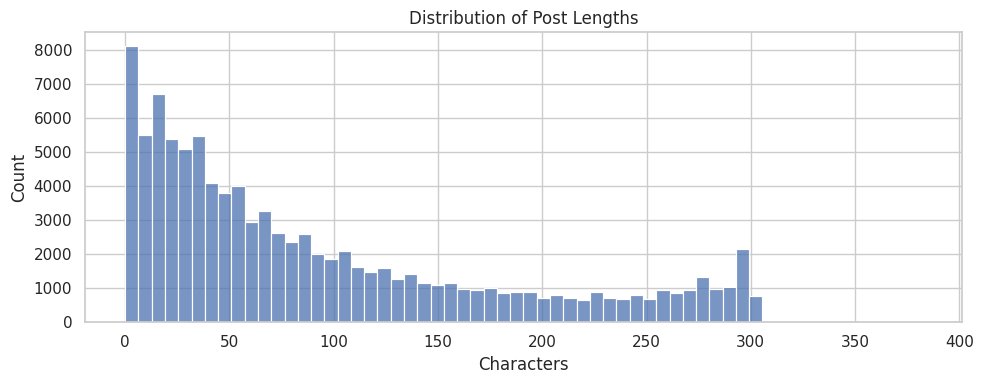

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["text_length"].dropna(), bins=60, ax=ax)
ax.set(title="Distribution of Post Lengths", xlabel="Characters", ylabel="Count")
plt.tight_layout()
plt.show()

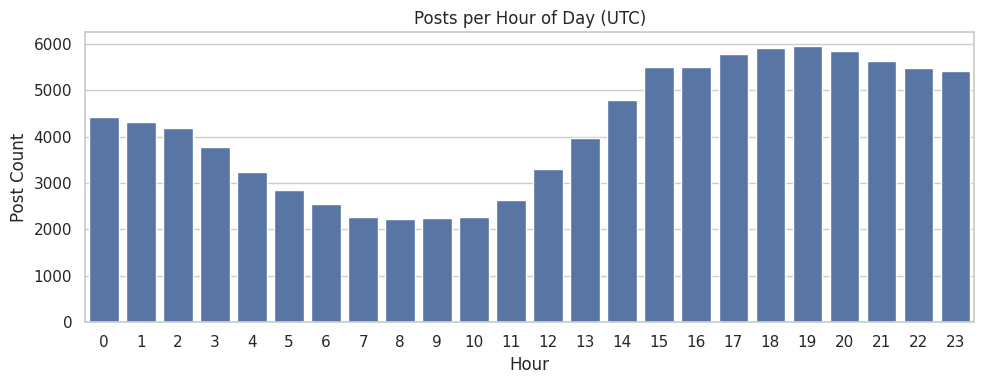

In [22]:

df["hour"] = df["timestamp"].dt.hour
posts_per_hour = df.groupby("hour").size().reindex(range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=posts_per_hour.index, y=posts_per_hour.values, ax=ax)
ax.set(title="Posts per Hour of Day (UTC)", xlabel="Hour", ylabel="Post Count")
plt.tight_layout()
plt.show()

In [23]:
#save sample to drive
df.to_csv(SAVE_PATH, index=False)
print(f"Saved {len(df):,} rows to {SAVE_PATH}")

Saved 100,000 rows to /content/drive/MyDrive/bluesky_filtered/posts_sample.csv


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   post_id       100000 non-null  int64         
 1   user_id       100000 non-null  int64         
 2   text          100000 non-null  object        
 3   date          100000 non-null  int64         
 4   like_count    100000 non-null  int64         
 5   reply_count   100000 non-null  int64         
 6   repost_count  100000 non-null  int64         
 7   is_reply      100000 non-null  bool          
 8   is_repost     100000 non-null  bool          
 9   is_quote      100000 non-null  bool          
 10  label         0 non-null       object        
 11  sent_label    88590 non-null   float64       
 12  sent_score    88590 non-null   float64       
 13  timestamp     100000 non-null  datetime64[ns]
 14  text_length   100000 non-null  int64         
 15  hour          1000

In [25]:
combined= df["like_count"]+df["repost_count"]
print(combined.describe())
print(combined.quantile([0.5,0.75,0.9,0.95,0.99]))

count    100000.000000
mean        253.017020
std        1445.333384
min           0.000000
25%           0.000000
50%           2.000000
75%          10.000000
max       30416.000000
dtype: float64
0.50       2.00
0.75      10.00
0.90     263.00
0.95    1037.05
0.99    5256.18
dtype: float64


#Using a virality threshold  such as top 10% (like +repost count)

In [29]:
threshold=combined.quantile(0.9)
df["is_viral"] = (combined >= threshold).astype(int)
print(f"Threshold: {threshold}")
print(df["is_viral"].value_counts())
print(f"Viral rate: {df['is_viral'].mean()*100:.1f}%")

Threshold: 263.0
is_viral
0    89996
1    10004
Name: count, dtype: int64
Viral rate: 10.0%


Filtering to choose superior to 30

In [30]:
candidates = df[df["text_length"] > 30].copy()
# If engagement fields exist:

candidates = candidates[candidates["like_count"] + candidates["repost_count"] > 0]

#Choose a sample of 3000 using seed 42

In [31]:
label_sample = candidates.sample(3000, random_state=42)
label_sample.info()
label_sample.to_csv("label_sample.csv", index=False)
print(f"Sampled {len(label_sample):,} posts")
print(f"Viral in sample: {label_sample['is_viral'].sum()} ({label_sample['is_viral'].mean()*100:.1f}%)")

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 70967 to 68653
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   post_id       3000 non-null   int64         
 1   user_id       3000 non-null   int64         
 2   text          3000 non-null   object        
 3   date          3000 non-null   int64         
 4   like_count    3000 non-null   int64         
 5   reply_count   3000 non-null   int64         
 6   repost_count  3000 non-null   int64         
 7   is_reply      3000 non-null   bool          
 8   is_repost     3000 non-null   bool          
 9   is_quote      3000 non-null   bool          
 10  label         0 non-null      object        
 11  sent_label    2793 non-null   float64       
 12  sent_score    2793 non-null   float64       
 13  timestamp     3000 non-null   datetime64[ns]
 14  text_length   3000 non-null   int64         
 15  hour          3000 non-null   int32   

In [32]:
!pip install google-genai

In [ ]:
import os
os.environ["GEMINI_API_KEY"] = "api-key"

In [ ]:
from google import genai
import os

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2

#This is the few shot learning (use of Gemini 2.5 flash) (price and availability reasons)

In [ ]:
!python /content/drive/MyDrive/bluesky_filtered/step2_label_emotions.py

Loaded 3,000 posts from label_sample.csv
Labeling:   3% 90/3000 [00:30<59:46,  1.23s/it]  [WARN] idx=1247 failed after 3 attempts: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Labeling:  14% 411/3000 [01:52<38:02,  1.13it/s][WARN] idx=1937 failed after 3 attempts: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Labeling: 100% 3000/3000 [10:26<00:00,  4.79it/s]

Done. Saved 3,000 rows to label_sample_emotions4.csv

Emotion distribution:
  joy         1,232   41.1%  ████████████████
  neutral     1,204   40.1%  ████████████████
  moral_outrage    317   10.6%  ████
  sadness       160    5.3%  ██
  anger          87    2.9%  █

Low-confidence labels (<0.7): 774 (25.8%)
Consider reviewing these man

First result shows very high results in terms of joy and neutral, perhaps confusing stuff for neutral. Yet anger and sadness are quite low annoying as the negative emotions are strong factors to virality.

#First pass of emotion labelling

In [33]:
import pandas as pd

df = pd.read_csv("label_sample_emotions4.csv")
df.info()

df.to_parquet("/content/drive/MyDrive/bluesky_filtered/label_sample_emotions4.parquet", index=False)
print("Saved as parquet")

# neutral_sample = df[df["emotion"] == "neutral"].sample(100, random_state=42)
# pd.set_option("display.max_colwidth", None)
# print(neutral_sample[["text", "emotion_confidence"]].to_string())

FileNotFoundError: [Errno 2] No such file or directory: 'label_sample_emotions4.csv'

In [34]:
df=pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_sample_emotions4.parquet")

In [35]:
df[df["emotion"]=="joy"].sample(20)[["text","emotion_confidence"]]

,text,emotion_confidence
1873,"Hedgehogs!\n\nAcross the UK, as the weather wa...",0.75
636,bad ass temple tattoo idea!\n[hypmic][ヒプマイ],0.65
1067,รู้สึกไถบลูสกายได้ปลอดภัยมาก เพราะถ้าเป็นทวิตเ...,0.75
1347,"While waiting for my flight to Guatemala, I re...",0.85
2440,This was intended to be a group of strong fema...,0.75
2988,Imposter Vincent spotted last weekend.\nSuch a...,0.75
2352,it's beautiful outside and I saw ducks!,0.90
2302,We just crossed 5M people total on the network...,0.95
256,"And as announced, I would like to introduce yo...",0.65
1141,"Love the list, especially ffx and silent hill 🙌",0.85


The identification of joy seems pretty relevant when manually checking obviously this is only for a sample however at first glance seems to work. Perhaps it is worth to have a cross checker or that might be too much computation.

#We do not have a great class distribution

*   Looking to add more angry examples to reach (300) will make it difficult to learn a certain class if there is only so much of it
*   Same for sadness hopefully



In [36]:
# Exclude them from candidates before sampling
candidates_new = candidates[~candidates["post_id"].isin(df["post_id"])]

label_sample = candidates_new.sample(47000, random_state=42)
label_sample.to_csv("sad_angry_label_csv")
print(f"Sampled {len(label_sample):,} posts")
#very trivial viral definition
print(f"Viral in sample: {label_sample['is_viral'].sum()} ({label_sample['is_viral'].mean()*100:.1f}%)")

Sampled 47,000 posts
Viral in sample: 6915 (14.7%)


In [37]:
df_raw=pd.read_csv("sad_angry_label_csv")
# Pull likely-anger posts
anger_candidates = df_raw[
    df_raw["text"].str.contains(
        r"can't believe|ridiculous|so annoying|pathetic|furious|unacceptable|disgrace|sick of|outraged|infuriating|how dare|absolutely done|fed up|drives me mad|makes me angry|pissed|livid|enraged|beyond frustrated|what the hell|are you serious|this is insane|losing my mind",


        case=False, na=False, regex=True
    )
]

# Pull likely-sadness posts
sadness_candidates = df_raw[
    df_raw["text"].str.contains(
        r"miss |lost |grief|heartbroken|devastated|wish things|so tired|hopeless|lonely",
        case=False, na=False, regex=True
    )
]

# Sample and save as new labeling input
anger_candidates.sample(min(500, len(anger_candidates)))[["text","post_id"]].to_csv("label_anger_boost.csv", index=False)
sadness_candidates.sample(min(500, len(sadness_candidates)))[["text","post_id"]].to_csv("label_sadness_boost.csv", index=False)

df_anger=pd.read_csv("label_anger_boost.csv")
df_sadness=pd.read_csv("label_sadness_boost.csv")
print(f"Length of anger is {len(df_anger)}, sadness is {len(df_sadness)}")

Length of anger is 193, sadness is 416


Combine them

In [38]:
combined = pd.concat([
    pd.read_csv("label_anger_boost.csv"),
    pd.read_csv("label_sadness_boost.csv")
]).drop_duplicates(subset=["text"])

combined.to_csv("label_boost_combined.csv", index=False)

In [39]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 568 entries, 0 to 415
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     568 non-null    object
 1   post_id  568 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.3+ KB


In [ ]:
!python /content/drive/MyDrive/bluesky_filtered/step2_label_emotions.py

Loaded 568 posts from label_boost_combined.csv
Labeling:  20% 112/568 [00:24<06:52,  1.11it/s][WARN] idx=341 failed after 3 attempts: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Labeling:  20% 115/568 [00:29<08:33,  1.13s/it][WARN] idx=188 failed after 3 attempts: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Labeling:  72% 407/568 [01:39<00:43,  3.73it/s][WARN] idx=497 failed after 3 attempts: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Labeling: 100% 568/568 [02:18<00:00,  4.11it/s]

Done. Saved 568 rows to label_boost_combined_emotions.csv


#Difficulties encountered


*   Despite having chosen angry possible words seems that the size of that dataset did not have as much impact as the sadness candidates (142 identified for 416 against 54 identified for 193)
*   It seems that anger is displayed under different keywords and a lot of the anger keywords are not used for an angry sentence but more so for sarcasm or neutral/joy sentences



In [40]:
import pandas as pd

df = pd.read_csv("label_boost_combined_emotions.csv") # labeled file
df.to_parquet("/content/drive/MyDrive/bluesky_filtered/label_boost_combined_emotions.parquet", index=False)
print("Saved as parquet")

FileNotFoundError: [Errno 2] No such file or directory: 'label_boost_combined_emotions.csv'

In [41]:
df=pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_boost_combined_emotions.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   idx                 568 non-null    int64  
 1   text                568 non-null    object 
 2   post_id             568 non-null    int64  
 3   emotion             568 non-null    object 
 4   emotion_confidence  568 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 22.3+ KB


We keep "post_id" as that will allow us to pick different candidates later on

In [ ]:
anger_mask = df_raw[~df_raw["post_id"].isin(df["post_id"])]["text"].str.contains(
    r"can't believe|ridiculous|furious|unacceptable|fed up|pissed|livid|enraged|beyond frustrated|how dare|makes me angry|losing my mind",
    case=False, na=False, regex=True
)
print(f"Remaining anger candidates: {anger_mask.sum():,}")


Remaining anger candidates: 11


Bag of words approach here if this word is in it than potential candidate used to artificially inflate result for the gemini labelling

Combine final output of both

In [42]:
df1 = pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_sample_emotions4.parquet")
df2 = pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_boost_combined_emotions.parquet")

df_final = pd.concat([df1, df2]).drop_duplicates(subset=["text"])
df_final = df_final[df_final["emotion_confidence"] >= 0.75]
df_final.to_csv("label_final.csv", index=False)
print(df_final["emotion"].value_counts())

emotion
joy              1142
neutral           531
moral_outrage     353
sadness           200
anger             107
Name: count, dtype: int64


In [43]:
low_conf = df[df["emotion_confidence"] < 0.7]
print(f"Total low confidence: {len(low_conf)}")
print(low_conf["emotion"].value_counts())
low_conf.sample(50 )[["text", "emotion", "emotion_confidence"]].to_string()

Total low confidence: 125
emotion
neutral          52
sadness          38
joy              25
anger             9
moral_outrage     1
Name: count, dtype: int64


'                                                                                                                                                                                                                                                                                                       text        emotion  emotion_confidence\n237                                                                        🍄 Forest Thoughts 🌿\\n\\n“Alone with her thoughts... in silence and solitude, but never lonely as she sits surrounded by the once wandering spirits - the wilderness, busy creatures and plantlife of the vibrant magical forest.“        neutral                0.60\n518                                                                                                                                                                                                                        I miss working on Windows. It was often highly stressful, but also a lot of fun.        sadness           

This is very interesting as it shows that in mpw confidence neutral/sadness/joy rank much higher, perhaps meaning there is a possibility of misclassification which is directly impacting the anger and moral_outrage classes, also moral outrage prompting was done well

In [44]:
df_labeled = pd.read_csv("label_final.csv")
print(df_labeled.columns.tolist())
print(df_labeled.shape)

['idx', 'post_id', 'user_id', 'text', 'date', 'like_count', 'reply_count', 'repost_count', 'is_reply', 'is_repost', 'is_quote', 'label', 'sent_label', 'sent_score', 'timestamp', 'text_length', 'hour', 'is_viral', 'emotion', 'emotion_confidence']
(2333, 20)


#First model which uses a SBert encoder to embed the sentence and then use Logstic Regression to classify
The use of stratify is important as to keep an equal class distribution to get some representative results

In [170]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

model = SentenceTransformer("all-MiniLM-L6-v2") #import a sentence decoder SBERT
X = model.encode(df_labeled["text"].tolist(), show_progress_bar=True) # 2. Calculate embeddings by calling model.encode()
y = df_labeled["emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test)))

# Save the classifier
joblib.dump(clf, "emotion_classifier.pkl")
joblib.dump(model, "sentence_encoder.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/73 [00:00<?, ?it/s]

               precision    recall  f1-score   support

        anger       0.24      0.48      0.32        21
          joy       0.90      0.72      0.80       229
moral_outrage       0.70      0.76      0.73        71
      neutral       0.58      0.66      0.62       106
      sadness       0.50      0.57      0.53        40

     accuracy                           0.69       467
    macro avg       0.58      0.64      0.60       467
 weighted avg       0.73      0.69      0.70       467



['sentence_encoder.pkl']

Pretty terrible precision on anger which would result in introducing noise later on in the model which is not great.

In [87]:
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test, clf.predict(X_test))
print(f"SBERT MCC: {mcc:.3f}")

SBERT MCC: 0.567


Use of this off CK's recommendation,  F1 ignores True Negative:
Joy is my highest class
F1 is precision × recall based:


Precision = TP / (TP + FP)   — of all joy predictions, how many were right
Recall    = TP / (TP + FN)   — of all actual joy posts, how many did you find
TN never appears. For imbalanced data this is a problem, a model can score high F1 on joy by just predicting joy constantly, and TN (correctly rejecting non-joy) gets no credit.

MCC uses all four:


MCC = (TP×TN - FP×FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN))
A model has to get both positives AND negatives right to score well — that's why it's harder to inflate on imbalanced datasets like yours.

#Here I am looking to get more anger_candidates in order to boost my results and trainability

In [48]:
anger_candidates2 = df_raw[
    ~df_raw["post_id"].isin(df_final["post_id"]) &  # exclude already labeled
    df_raw["text"].str.contains(
        r"pissed off|so done|drives me insane|losing my mind|makes me so mad|"
        r"i hate when|why the hell|what the hell|are you kidding|"
        r"i'm done with|so frustrated|beyond annoyed|genuinely annoyed|"
        r"i cannot stand|this is so stupid|so bloody|f\*cking|"
        r"ugh|ughhh|arghhh|ffs|wtf",
        case=False, na=False, regex=True
    )
]

print(f"New anger candidates: {len(anger_candidates2):,}")
anger_candidates2.sample(600, random_state=42)[["post_id", "text"]]\
    .to_csv("label_anger_boost2.csv", index=False)


New anger candidates: 2,581


Surprisingly a lot of anger candidates using more passionate expressions, such as cussing and strong expressions

In [51]:
!python /content/drive/MyDrive/bluesky_filtered/step2_label_emotions.py

Loaded 600 posts from label_anger_boost2.csv
Labeling: 100% 600/600 [01:27<00:00,  6.85it/s]

Done. Saved 600 rows to label_anger_boost2_emotions.csv

Emotion distribution:
  joy           265   44.2%  █████████████████
  neutral       209   34.8%  █████████████
  moral_outrage     66   11.0%  ████
  sadness        44    7.3%  ██
  anger          16    2.7%  █

Low-confidence labels (<0.7): 161 (26.8%)
Consider reviewing these manually in Step 3.


In [53]:
pd.read_csv("label_anger_boost2_emotions.csv").to_parquet("/content/drive/MyDrive/bluesky_filtered/label_anger_boost2_emotions.parquet", index=False) # labeled file

print("Saved as parquet")

Saved as parquet


##In this phase I proceeded to add labeled data for the lacking labels(anger)

I merge anger into moral outrage to hopefully get a higher result

In [54]:
df1 = pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_sample_emotions4.parquet")
df2 = pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_boost_combined_emotions.parquet")
df3 = pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_anger_boost2_emotions.parquet")

# Combine all three
df_final = pd.concat([df1, df2, df3]).drop_duplicates(subset=["text"])

# Filter low confidence
df_final = df_final[df_final["emotion_confidence"] >= 0.75]

# Merge anger into moral_outrage
df_final["emotion"] = df_final["emotion"].replace("anger", "moral_outrage")

print(df_final["emotion"].value_counts())
print(f"\nTotal: {len(df_final):,}")

# Save
df_final.to_csv("label_final.csv", index=False)
df_final.to_parquet("/content/drive/MyDrive/bluesky_filtered/label_final.parquet", index=False)
print("Saved.")


emotion
joy              1352
neutral           610
moral_outrage     531
sadness           229
Name: count, dtype: int64

Total: 2,722
Saved.


Merged anger into moral outrage as the original model was getting very low results, to see if this would improve overall

In [55]:
sadness_candidates2 = df_raw[
    ~df_raw["post_id"].isin(df_final["post_id"]) &
    df_raw["text"].str.contains(
        r"i miss |i missed|missing you|miss him|miss her|miss them|"
        r"passed away|lost my |lost him|lost her|we lost|"
        r"i'm heartbroken|heartbroken|devastated|gutted|"
        r"i'm grieving|grief|grieving|mourning|"
        r"i cried|been crying|can't stop crying|"
        r"i feel empty|feel so empty|feel so alone|so alone|"
        r"i give up|giving up|what's the point|no hope|"
        r"i'm struggling|really struggling|hard to keep going|"
        r"i'm exhausted|mentally exhausted|emotionally drained",
        case=False, na=False, regex=True
    )
]

print(f"New sadness candidates: {len(sadness_candidates2):,}")
sadness_candidates2.sample(min(600, len(sadness_candidates2)), random_state=42)[["post_id", "text"]]\
    .to_csv("label_sadness_boost2.csv", index=False)


New sadness candidates: 121


Adding more sadness candidates with use of keywords, to then run through the step2_label_emotions.py

In [56]:
!python /content/drive/MyDrive/bluesky_filtered/step2_label_emotions.py

Loaded 121 posts from label_sadness_boost2.csv
Labeling: 100% 121/121 [00:20<00:00,  6.03it/s]

Done. Saved 121 rows to label_sadness_boost2_emotions.csv

Emotion distribution:
  sadness        58   47.9%  ███████████████████
  joy            33   27.3%  ██████████
  neutral        24   19.8%  ███████
  moral_outrage      6    5.0%  █

Low-confidence labels (<0.7): 40 (33.1%)
Consider reviewing these manually in Step 3.


In [59]:
pd.read_csv("label_sadness_boost2_emotions.csv").to_parquet("/content/drive/MyDrive/bluesky_filtered/label_sadness_boost2_emotions.parquet", index=False) # labeled file

print("Saved as parquet")

Saved as parquet


In [62]:
df4=pd.read_parquet("/content/drive/MyDrive/bluesky_filtered/label_sadness_boost2_emotions.parquet")

# Combine all three
df_final = pd.concat([df1, df2, df3,df4]).drop_duplicates(subset=["text"])

# Filter low confidence
df_final = df_final[df_final["emotion_confidence"] >= 0.75]

# Merge anger into moral_outrage
df_final["emotion"] = df_final["emotion"].replace("anger", "moral_outrage")

print(df_final["emotion"].value_counts())
print(f"\nTotal: {len(df_final):,}")

# Save
df_final.to_csv("label_final.csv", index=False)
df_final.to_parquet("/content/drive/MyDrive/bluesky_filtered/label_final.parquet", index=False)
print("Saved.")

emotion
joy              1371
neutral           617
moral_outrage     536
sadness           261
Name: count, dtype: int64

Total: 2,785
Saved.


In [89]:
df_final["emotion"].value_counts()

,count
emotion,
joy,1371
neutral,617
moral_outrage,536
sadness,261


Using an original architecture of SBERT plus Logistic Regression, merged here however with merged anger to moral outrage because both are similar results and while I'm comprimising complexity I believe I will get a higher result

In [90]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

model2 = SentenceTransformer("all-MiniLM-L6-v2") #import a sentence decoder SBERT
X = model.encode(df_final["text"].tolist(), show_progress_bar=True) # 2. Calculate embeddings by calling model.encode()
y = df_final["emotion"]

X_train_merge, X_test_merge, y_train_merge, y_test_merge = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf_merge = LogisticRegression(max_iter=1000, class_weight="balanced")
clf_merge.fit(X_train_merge, y_train_merge)

print(classification_report(y_test_merge, clf_merge.predict(X_test_merge)))

# Save the classifier
joblib.dump(clf_merge, "emotion_classifier.pkl")
joblib.dump(model, "sentence_encoder.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

               precision    recall  f1-score   support

          joy       0.83      0.74      0.78       274
moral_outrage       0.76      0.79      0.77       107
      neutral       0.58      0.65      0.61       124
      sadness       0.48      0.60      0.53        52

     accuracy                           0.71       557
    macro avg       0.66      0.69      0.68       557
 weighted avg       0.73      0.71      0.72       557



['sentence_encoder.pkl']

In [91]:
from sklearn.metrics import matthews_corrcoef
mcc_merge = matthews_corrcoef(y_test_merge, clf_merge.predict(X_test_merge))
print(f"SBERT MCC (anger/moral outrage merged): {mcc_merge:.3f} vs SBERT MCC (no merge):{mcc:.3f}")

SBERT MCC (anger/moral outrage merged): 0.583 vs SBERT MCC (no merge):0.567


Slightly higher  MCC from 0.583=>0.567 meaning that reducing the complexity only offer slight improvement. All in all this is not worth losing the meaning/ reducing complexity.


Comparing Scores

In [93]:
print("=" * 60)
print("5-CLASS MODEL (anger separate)")
print("=" * 60)
print(classification_report(y_test, clf.predict(X_test)))

print("=" * 60)
print("4-CLASS MODEL (anger merged into moral_outrage)")
print("=" * 60)
print(classification_report(y_test_merge, clf_merge.predict(X_test_merge)))


5-CLASS MODEL (anger separate)
               precision    recall  f1-score   support

        anger       0.24      0.48      0.32        21
          joy       0.90      0.72      0.80       229
moral_outrage       0.70      0.76      0.73        71
      neutral       0.58      0.66      0.62       106
      sadness       0.50      0.57      0.53        40

     accuracy                           0.69       467
    macro avg       0.58      0.64      0.60       467
 weighted avg       0.73      0.69      0.70       467

4-CLASS MODEL (anger merged into moral_outrage)
               precision    recall  f1-score   support

          joy       0.83      0.74      0.78       274
moral_outrage       0.76      0.79      0.77       107
      neutral       0.58      0.65      0.61       124
      sadness       0.48      0.60      0.53        52

     accuracy                           0.71       557
    macro avg       0.66      0.69      0.68       557
 weighted avg       0.73      0.71  

## SBERT + Logistic Regression: 5-class vs 4-class Comparison

### Key Findings

- **4-class model outperforms SBERT+LR on all metrics** — macro F1 0.68 vs 0.60, accuracy 0.71 vs 0.69, MCC 0.583 vs 0.567
- **Merging anger improves moral_outrage** — F1 rises from 0.73 → 0.77 as the class boundary tightens
- **Anger at F1 0.32 actively hurts SBERT+LR** — precision 0.24 introduces enough false positives to drag macro F1 down by 0.08
- **Joy is the strongest class in both models** — F1 0.80/0.78, consistent and stable regardless of anger treatment
- **Sadness is unchanged by the merge** — F1 0.53 in both models, suggesting it is an independently difficult class
- **SBERT+LR cannot learn the anger/moral_outrage boundary** — the marginal MCC gain (0.567 → 0.583) confirms merging is the correct decision for this architecture
- **The transformer tells a different story** — MCC 0.666 with anger separate vs 0.580 merged, meaning the fine-tuned RoBERTa has learned a genuine anger signal SBERT+LR cannot capture
- **Model choice determines class structure** — use 4-class with SBERT+LR, 5-class with the transformer




#Another attempt to boost the anger training accuracy

In [107]:
# Posts the sentiment model thinks are negative
# but your emotion model hasn't seen yet
anger_candidates = df_raw[
    ~df_raw["post_id"].isin(df_final["post_id"]) &
    (df_raw["sent_label"] == 0.0)
]
print(f"Negative sentiment unlabeled: {len(anger_candidates):,}")


Negative sentiment unlabeled: 9,016


Using the `sent_label` column which represents the sentiment of the post:
*   `0.0` corresponds to **Negative** sentiment.
*   `1.0` corresponds to **Neutral** sentiment.
*   `2.0` corresponds to **Positive** sentiment.

We find the negative sentiments that are not yet labeled showing that there is still a gap in what we have preprocessed or the gemini few shot approach has correctly labelled

In [110]:
# Sample 1,200 from negative sentiment pool
anger_candidates.sample(3000, random_state=42)[["post_id", "text"]]\
    .to_csv("label_anger_boost4.csv", index=False)


In [123]:
!python /content/drive/MyDrive/bluesky_filtered/step2_label_emotions.py

Loaded 3,000 posts from label_anger_boost4.csv
Labeling:  32% 962/3000 [02:13<04:24,  7.71it/s][WARN] idx=1127 failed after 3 attempts: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Labeling: 100% 3000/3000 [07:03<00:00,  7.09it/s]

Done. Saved 3,000 rows to label_anger_boost4_emotions.csv

Emotion distribution:
  moral_outrage    963   32.1%  ████████████
  neutral       713   23.8%  █████████
  joy           593   19.8%  ███████
  sadness       416   13.9%  █████
  anger         315   10.5%  ████

Low-confidence labels (<0.7): 1,029 (34.3%)
Consider reviewing these manually in Step 3.


#

In [150]:
df5=pd.read_csv("label_anger_boost4_emotions.csv")
df5.info()
# Combine all three
df_final = pd.concat([df1, df2, df3,df4,df5]).drop_duplicates(subset=["text"])

# Filter low confidence
df_final = df_final[df_final["emotion_confidence"] >= 0.75]

# # Merge anger into moral_outrage
# df_final["emotion"] = df_final["emotion"].replace("anger", "moral_outrage")

print(df_final["emotion"].value_counts())
print(f"\nTotal: {len(df_final):,}")

# Save
df_final.to_csv("label_final.csv", index=False)
df_final.to_parquet("/content/drive/MyDrive/bluesky_filtered/label_final.parquet", index=False)
print("Saved.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   idx                 3000 non-null   int64  
 1   post_id             3000 non-null   int64  
 2   text                3000 non-null   object 
 3   emotion             3000 non-null   object 
 4   emotion_confidence  3000 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 117.3+ KB
emotion
joy              1670
moral_outrage    1229
neutral           734
sadness           528
anger             348
Name: count, dtype: int64

Total: 4,509
Saved.


In [125]:
df_final["emotion"].describe()

,emotion
count,2785
unique,5
top,joy
freq,1371


#Same model architecture as before now looking to boost with extra anger and moral outrage all in all

In [151]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

model3 = SentenceTransformer("all-MiniLM-L6-v2") #import a sentence decoder SBERT
X = model.encode(df_final["text"].tolist(), show_progress_bar=True) # 2. Calculate embeddings by calling model.encode()
y = df_final["emotion"]

X_train_boost, X_test_boost, y_train_boost, y_test_boost = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf_boost = LogisticRegression(max_iter=1000, class_weight="balanced")
clf_boost.fit(X_train_boost, y_train_boost)

print(classification_report(y_test_boost, clf_boost.predict(X_test_boost)))

# Save the classifier
joblib.dump(clf_boost, "emotion_classifier.pkl")
joblib.dump(model, "sentence_encoder.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

               precision    recall  f1-score   support

        anger       0.28      0.49      0.36        69
          joy       0.79      0.55      0.65       334
moral_outrage       0.78      0.75      0.76       246
      neutral       0.48      0.59      0.52       147
      sadness       0.49      0.60      0.54       106

     accuracy                           0.61       902
    macro avg       0.56      0.60      0.57       902
 weighted avg       0.66      0.61      0.62       902



['sentence_encoder.pkl']

Adding more data did not necassirily better the result

##New Model architecture **RobertaFacebookBERT** nlp model

In [152]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ── Data ─────────────────────────────────────────────────────────────────────

df = df_final

label2id = {"joy": 0, "moral_outrage": 1, "neutral": 2, "sadness": 3,"anger": 4}
id2label = {v: k for k, v in label2id.items()} #mapping to numbers

df["label"] = df["emotion"].map(label2id)
df = df.dropna(subset=["label", "text"]) #maps to a number for neural network

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42) #stratify guarantees the distribution is equal in very split

# ── Tokenize ──────────────────────────────────────────────────────────────────

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest" #the cardiff nlp model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128) #built in function to tokenize token is part of word ("AI is amazing")=> AI/is/ama/zing  128 as most social media post are around 40 allows faster computing time

#transform to hugging face dataset
train_ds = Dataset.from_pandas(train_df[["text", "label"]]).map(tokenize, batched=True) #batched=True — processes chunks of rows simultaneously on GPU, much faster
test_ds  = Dataset.from_pandas(test_df[["text", "label"]]).map(tokenize, batched=True)#runs tokenize across whole thing

# ── Model ─────────────────────────────────────────────────────────────────────

model = AutoModelForSequenceClassification.from_pretrained(         #this allows to add more classification heads on it what we need as Roberta is only three classification heads, ingore mismatched sizes
    MODEL_NAME,
    num_labels=5,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1) #across columns
    report = classification_report(labels, preds, target_names=label2id.keys(), output_dict=True)
    return {"f1_macro": report["macro avg"]["f1-score"]}  #macro f1 as not the same number of classes in dataset

# ── Training ──────────────────────────────────────────────────────────────────
# learning_rate=2e-5   # sweet spot for fine-tuning: 1e-5 to 5e-5
# weight_decay=0.01    # standard L2 regularisation
# num_train_epochs=4   # 3-5 is always the range for this dataset size
# batch_size=32        # limited by your GPU memory, not a tunable
args = TrainingArguments(
    output_dir="emotion_model",
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="best",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

# ── Evaluate ──────────────────────────────────────────────────────────────────

preds = np.argmax(trainer.predict(test_ds).predictions, axis=-1)
print(classification_report(test_df["label"], preds, target_names=label2id.keys()))

# ── Save ──────────────────────────────────────────────────────────────────────

model.save_pretrained("/content/drive/MyDrive/bluesky_filtered/emotion_model")
tokenizer.save_pretrained("/content/drive/MyDrive/bluesky_filtered/emotion_model")
print("Saved.")


Map:   0%|          | 0/3607 [00:00<?, ? examples/s]

Map:   0%|          | 0/902 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
roberta.pooler.dense.bias       | UNEXPECTED |                                                                                     
roberta.pooler.dense.weight     | UNEXPECTED |                                                                                     
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([5])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs mod

Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.634530,0.727187
2,No log,0.629477,0.737440
3,No log,0.690093,0.736613
4,No log,0.676043,0.752886


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

               precision    recall  f1-score   support

          joy       0.85      0.81      0.83       334
moral_outrage       0.81      0.85      0.83       246
      neutral       0.76      0.75      0.75       147
      sadness       0.76      0.73      0.74       106
        anger       0.55      0.67      0.61        69

     accuracy                           0.79       902
    macro avg       0.75      0.76      0.75       902
 weighted avg       0.79      0.79      0.79       902



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved.


In [154]:
from sklearn.metrics import matthews_corrcoef
import numpy as np

# SBERT MCC — on test set
mcc_sbert_boost = matthews_corrcoef(y_test_boost, clf_boost.predict(X_test_boost))

# Transformer MCC — extract predictions from test set first
transformer_output = trainer.predict(test_ds)
transformer_preds  = np.argmax(transformer_output.predictions, axis=-1)
mcc_cardiff        = matthews_corrcoef(test_df["label"], transformer_preds)

print(f"SBERT+LR MCC booosted :              {mcc_sbert_boost:.3f}")
print(f"SBERT+LR MCC :              {mcc:.3f}")
print(f"Cardiff RoBERTa MCC:       {mcc_cardiff:.3f}")
print(f"Improvement over best sbert:               +{mcc_cardiff - mcc:.3f}")


SBERT+LR MCC booosted :              0.503
SBERT+LR MCC :              0.567
Cardiff RoBERTa MCC:       0.718
Improvement over best sbert:               +0.152


Noticable improve over the SBERT architecture but as observed more data extracted does not necessarily help as it introduces noise in oiur strongest label "joy"

In [165]:
print(type(sbert_preds[0]))   # numpy array uses [] not .iloc       # type of first element
print(y_test_int.dtype)                # dtype of the series
print(y_test.unique())             # see actual values
print(test_df["label"].dtype)      # check transformer labels too
print(transformer_preds.dtype)     # check transformer predictions


<class 'str'>
int64
['joy' 'anger' 'neutral' 'sadness' 'moral_outrage']
int64
int64


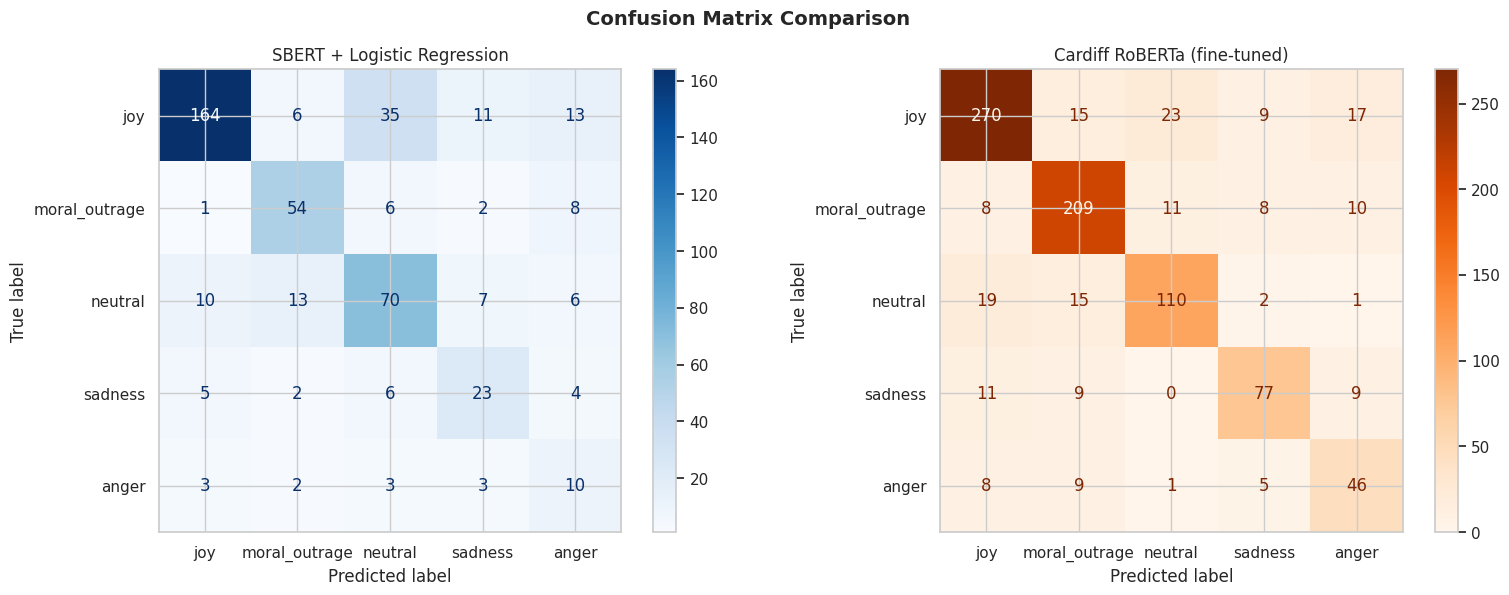

In [166]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# y_test is strings — map them to integers to match everything else same thing for X_test
y_test_int = y_test.map(label2id)
# Map sbert predictions to integers too
sbert_preds = pd.Series(clf.predict(X_test)).map(label2id)



# Transformer predictions
transformer_preds = np.argmax(trainer.predict(test_ds).predictions, axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SBERT+LR
cm_sbert = confusion_matrix(y_test_int, sbert_preds, labels=list(label2id.values()))
ConfusionMatrixDisplay(cm_sbert, display_labels=list(label2id.keys())).plot(
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("SBERT + Logistic Regression")

# Transformer
cm_transformer = confusion_matrix(test_df["label"], transformer_preds, labels=list(label2id.values()))
ConfusionMatrixDisplay(cm_transformer, display_labels=list(label2id.keys())).plot(
    cmap="Oranges", ax=axes[1]
)
axes[1].set_title("Cardiff RoBERTa (fine-tuned)")

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



## Confusion Matrix Analysis

### Joy
- **SBERT:** 164/229 correct — leaks into neutral (35) and sadness (11)
- **Transformer:** 270/334 correct — same neutral leak (23) but significantly stronger overall

### Moral Outrage
- **SBERT:** 54/71 correct — leaks into anger (8)
- **Transformer:** 209/246 correct — dramatic improvement, barely leaks anywhere

### Neutral
- **SBERT:** 70/106 correct — biggest confusion with moral_outrage (13)
- **Transformer:** 110/147 correct — still leaks into joy (19), joy/neutral boundary remains hard for both models

### Sadness
- **SBERT:** 23/40 correct — leaks heavily into neutral (6) and joy (5)
- **Transformer:** 77/106 correct — significant improvement, notably 0 sadness→neutral misclassifications

### Anger
- **SBERT:** 10/21 correct — barely better than random
- **Transformer:** 46/69 correct — genuinely learned anger as a distinct signal
* Not many leaks on the fintuned side, just joy and neutral leaks

In [171]:
# Re-run SBERT predictions on transformer's test set
X_test_shared = model.encode(test_df["text"].tolist(), show_progress_bar=True)
sbert_preds_shared = pd.Series(clf.predict(X_test_shared)).map(label2id).values

# Transformer predictions on same test set
transformer_preds_shared = np.argmax(trainer.predict(test_ds).predictions, axis=-1)

# Now both are length 902 — same posts
sbert_correct       = (sbert_preds_shared == test_df["label"].values)
transformer_correct = (transformer_preds_shared == test_df["label"].values)

# Build contingency table
table = [
    [(~sbert_correct & ~transformer_correct).sum(),
     (~sbert_correct &  transformer_correct).sum()],
    [( sbert_correct & ~transformer_correct).sum(),
     ( sbert_correct &  transformer_correct).sum()]
]

result = mcnemar(table, exact=False)
print(f"Statistic: {result.statistic:.4f}")
print(f"p-value:   {result.pvalue:.4f}")


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Statistic: 53.3787
p-value:   0.0000


McNemar's test confirms the transformer's superiority is statistically
significant (χ² = 53.38, p < 0.0001), ruling out the possibility that
the MCC improvement (0.567 → 0.666) is attributable to test set variance.


In [172]:
import os
print(os.listdir("/content/drive/MyDrive/bluesky_filtered/emotion_model"))



['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


In [173]:
from transformers import pipeline

emotion_clf = pipeline(
    "text-classification",
    model="/content/drive/MyDrive/bluesky_filtered/emotion_model",
    tokenizer="/content/drive/MyDrive/bluesky_filtered/emotion_model",
    device=0,
    local_files_only=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [174]:
# Quick sanity check on 5 posts
test_posts = [
    "Just got the job offer!! So excited 🎉",
    "This is what happens when nobody is held accountable.",
    "The UK base rate was held at 4.5% today.",
    "Miss my dog so much. Two years now.",
    "My neighbour has been drilling for 3 hours straight."
]

for post, result in zip(test_posts, emotion_clf(test_posts)):
  print(f"{result['label']:<15} {result['score']:.2f}  {post[:50]}")

joy             0.99  Just got the job offer!! So excited 🎉
moral_outrage   0.98  This is what happens when nobody is held accountab
neutral         0.98  The UK base rate was held at 4.5% today.
sadness         0.98  Miss my dog so much. Two years now.
anger           0.89  My neighbour has been drilling for 3 hours straigh


Testing it on some pretty strong examples furnished by AI I find that it scores pretty highly with a notable high score for anger which is more optimistic

Downloading model

In [175]:
from google.colab import files
import shutil

# Zip the model folder first
shutil.make_archive("/content/emotion_model", "zip", "/content/drive/MyDrive/bluesky_filtered/emotion_model")

# Download the zip
files.download("/content/emotion_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>